In [1]:
print("test")

test


# Banking FAQ Dataset - Exploratory Data Analysis (EDA)

## Objective
This notebook performs Exploratory Data Analysis (EDA) on the Banking FAQ Dataset.

The goals are:

- Understand dataset structure
- Analyze category distribution
- Explore question and answer patterns
- Perform NLP preprocessing
- Extract meaningful text insights
- Prepare clean data for ML, NLP, and RAG pipelines

## Dataset Information
- Total FAQs: 
- Categories: 10
- Domain: Indian Banking & Finance

### Import Libraries

In [2]:
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# NLP
import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Notebook settings
pd.set_option("display.max_colwidth", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Dataset

In [3]:
# Define folder path
data_folder = Path(
    "../data/raw_data/"
)

# Read all CSV files from the folder
all_files = list(data_folder.glob("*.csv"))

# Load and combine all datasets
df = pd.concat(
    [pd.read_csv(file) for file in all_files],
    ignore_index=True
)
# Display first 5 rows
df.head()

,Section,Question,Answer
0,Financial Markets,Give me details about mcx.,"Generally, MCX (Multi Commodity Exchange) is India's largest commodity derivatives exchange, where contracts for gold, silver, copper, crude oil, and other commodities are traded."
1,Basic Accounts,Can you explain an account opening bonus?,"From a banking perspective, Some banks offer cashback, welcome gifts, or reward points when you open a new account or upgrade to a premium account."
2,General Finance,Tell me about real estate investment.,"In simple words, Real estate investing means buying property — residential, commercial, or land — with the expectation of rental income or capital appreciation."
3,Customer Service,How does how do i avoid sim swap fraud work?,"Generally, Never share your mobile number or Aadhaar with strangers. If your SIM stops working suddenly, immediately call your telecom provider and bank to block access."
4,Customer Service,Give me details about how do i apply for a credit card.,"Generally, Apply on the bank's website, through the mobile app, or at the branch. You'll need income proof, PAN, and Aadhaar. Approval depends on income and credit score."


### Basic Dataset Inspection

#### Dataset Shape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (251000, 3)


#### Column Names

In [5]:
df.columns

Index(['Section', 'Question', 'Answer'], dtype='object')

#### Dataset Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251000 entries, 0 to 250999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Section   251000 non-null  object
 1   Question  251000 non-null  object
 2   Answer    251000 non-null  object
dtypes: object(3)
memory usage: 5.7+ MB


#### Random Samples

In [7]:
df.sample(5)

,Section,Question,Answer
160722,International Banking,What do you mean by What is the RBI's LRS limit? #59723,"Under the Liberalised Remittance Scheme, resident Indians can remit up to USD 2,50,000 per financial year for approved purposes like travel, education, and investment abroad."
173349,Digital Banking,What should I know about What is tokenization of cards? #72350,"Tokenization replaces your actual card number with a unique code (token) during online payments, so your real card details are never exposed."
93383,Customer Service,Why is how do i link aadhaar to my bank account important?,"Basically, You can link Aadhaar online via net banking, at an ATM, by SMS, or by visiting the branch with your Aadhaar. It's now voluntary but may be needed for certain benefits."
107464,Insurance & Govt Schemes,Why is What is a death benefit in insurance important? #6465,Death benefit is the amount paid to your nominee when you die during the active policy period.
82240,International Banking,What is the meaning of the special drawing right (sdr)?,"From a banking perspective, SDR is an international reserve asset created by the IMF. Its value is based on a basket of major currencies (USD, EUR, CNY, JPY, GBP). India holds SDRs as part of fore..."


### Missing Values & Duplicates

#### Missing Values

In [8]:
df.isnull().sum()

Section     0
Question    0
Answer      0
dtype: int64

#### Duplicate Rows

In [10]:
df.duplicated(subset=["Question"]).sum()

123070

#### # Remove duplicates

In [11]:
df.drop_duplicates(
    subset=["Question"],
    inplace=True
)

# Reset index
df.reset_index(
    drop=True,
    inplace=True
)

In [12]:
df.shape

(127930, 3)

### Category Distribution Analysis

#### Count Categories

In [13]:
section_counts = df['Section'].value_counts()

section_counts

Section
Basic Accounts              15379
Digital Banking             14966
Loans & Interest            14041
Operations & Security       13975
General Finance             13661
Financial Markets           11647
Customer Service            11597
Insurance & Govt Schemes    11393
Banking Terminology         11071
International Banking       10200
Name: count, dtype: int64

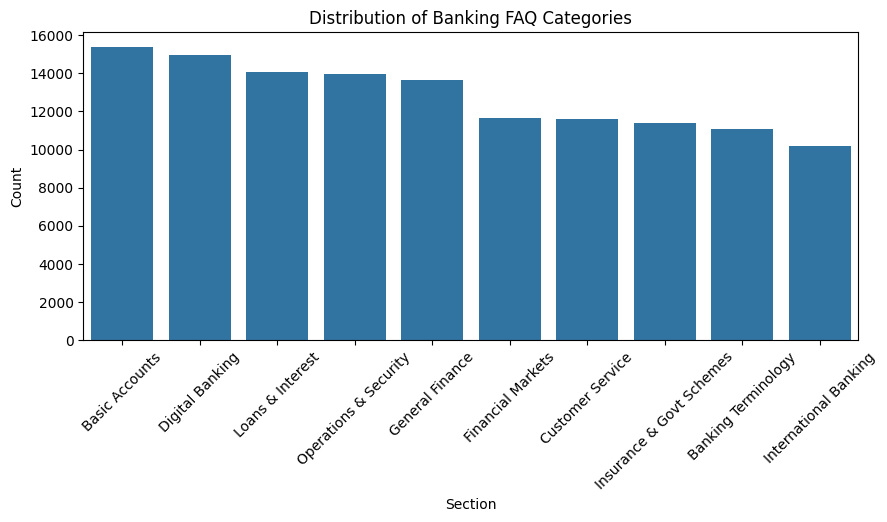

In [14]:
plt.figure(figsize=(10,4))

sns.barplot(
    x=section_counts.index,
    y=section_counts.values
)

plt.title("Distribution of Banking FAQ Categories")
plt.xlabel("Section")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### Question & Answer Length Analysis

#### Create Length Columns

In [15]:
df['question_length'] = df['Question'].apply(len)
df['answer_length'] = df['Answer'].apply(len)

df.head()

,Section,Question,Answer,question_length,answer_length
0,Financial Markets,Give me details about mcx.,"Generally, MCX (Multi Commodity Exchange) is India's largest commodity derivatives exchange, where contracts for gold, silver, copper, crude oil, and other commodities are traded.",26,179
1,Basic Accounts,Can you explain an account opening bonus?,"From a banking perspective, Some banks offer cashback, welcome gifts, or reward points when you open a new account or upgrade to a premium account.",41,147
2,General Finance,Tell me about real estate investment.,"In simple words, Real estate investing means buying property — residential, commercial, or land — with the expectation of rental income or capital appreciation.",37,160
3,Customer Service,How does how do i avoid sim swap fraud work?,"Generally, Never share your mobile number or Aadhaar with strangers. If your SIM stops working suddenly, immediately call your telecom provider and bank to block access.",44,169
4,Customer Service,Give me details about how do i apply for a credit card.,"Generally, Apply on the bank's website, through the mobile app, or at the branch. You'll need income proof, PAN, and Aadhaar. Approval depends on income and credit score.",55,170


#### Statistics

In [16]:
df[['question_length', 'answer_length']].describe()

,question_length,answer_length
count,127930.000000,127930.000000
mean,57.242383,154.820136
std,12.740128,24.083911
min,12.000000,85.000000
25%,49.000000,140.000000
50%,57.000000,152.000000
75%,65.000000,165.000000
max,118.000000,278.000000


#### Question Length Distribution

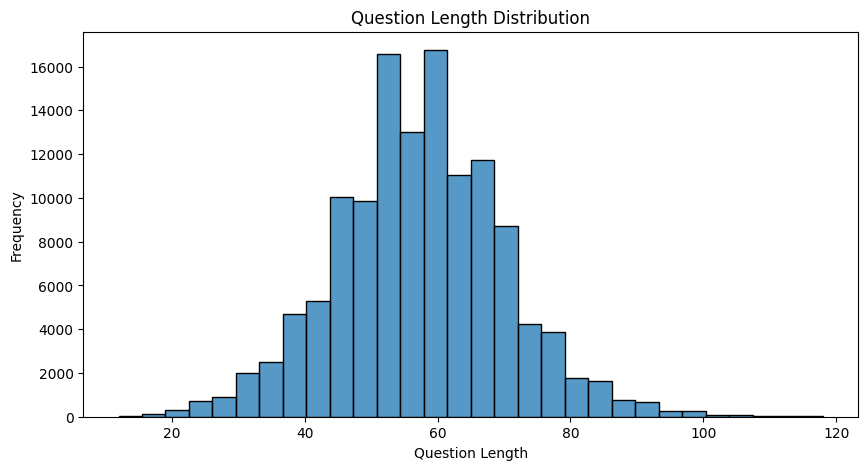

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df['question_length'], bins=30)

plt.title("Question Length Distribution")
plt.xlabel("Question Length")
plt.ylabel("Frequency")

plt.show()

#### Answer Length Distribution

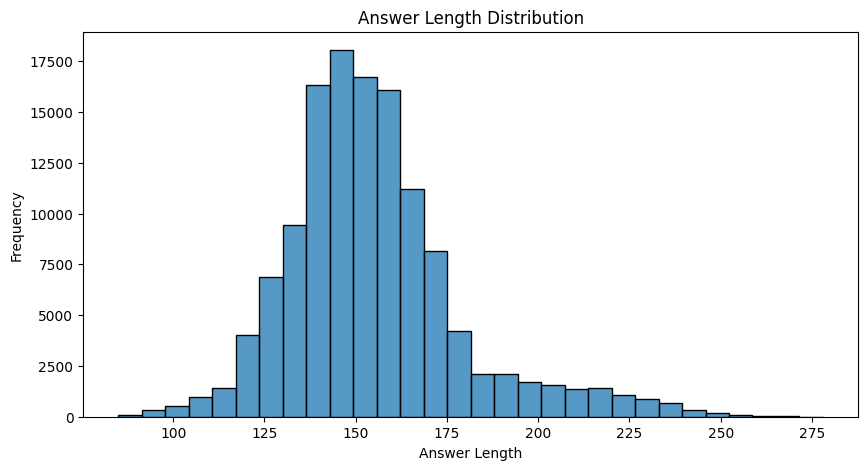

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['answer_length'], bins=30)

plt.title("Answer Length Distribution")
plt.xlabel("Answer Length")
plt.ylabel("Frequency")

plt.show()

### NLP Text Preprocessing

#### Load spaCy Model

In [19]:
nlp = spacy.load("en_core_web_sm")

#### Stopwords

In [20]:
stop_words = set(stopwords.words('english'))

#### Create Cleaning Function

In [21]:
def preprocess_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and non-alphabetic words
    tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    
    # Lemmatization
    doc = nlp(" ".join(tokens))
    
    lemmatized_tokens = [
        token.lemma_
        for token in doc
    ]
    
    return " ".join(lemmatized_tokens)

#### Apply Preprocessing

In [22]:
df['clean_question'] = df['Question'].apply(preprocess_text)

In [23]:
df[['Question', 'clean_question']].head()

,Question,clean_question
0,Give me details about mcx.,give detail mcx
1,Can you explain an account opening bonus?,explain account opening bonus
2,Tell me about real estate investment.,tell real estate investment
3,How does how do i avoid sim swap fraud work?,avoid sim swap fraud work
4,Give me details about how do i apply for a credit card.,give detail apply credit card


### Most Common Words

#### Combine All Questions

In [24]:
all_words = " ".join(df['clean_question']).split()

#### Count Words

In [25]:
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

common_words

[('bank', 26328),
 ('banking', 20499),
 ('explain', 16815),
 ('customer', 11247),
 ('account', 10809),
 ('loan', 10264),
 ('use', 10140),
 ('tell', 8789),
 ('mean', 8753),
 ('know', 7823),
 ('work', 7224),
 ('detail', 7207),
 ('could', 6985),
 ('give', 6903),
 ('credit', 6321),
 ('role', 6157),
 ('important', 6140),
 ('provide', 6030),
 ('benefit', 5708),
 ('card', 5664)]

#### Convert to DataFrame

In [26]:
common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Frequency']
)

common_words_df

,Word,Frequency
0,bank,26328
1,banking,20499
2,explain,16815
3,customer,11247
4,account,10809
5,loan,10264
6,use,10140
7,tell,8789
8,mean,8753
9,know,7823


#### Plot Most Common Words

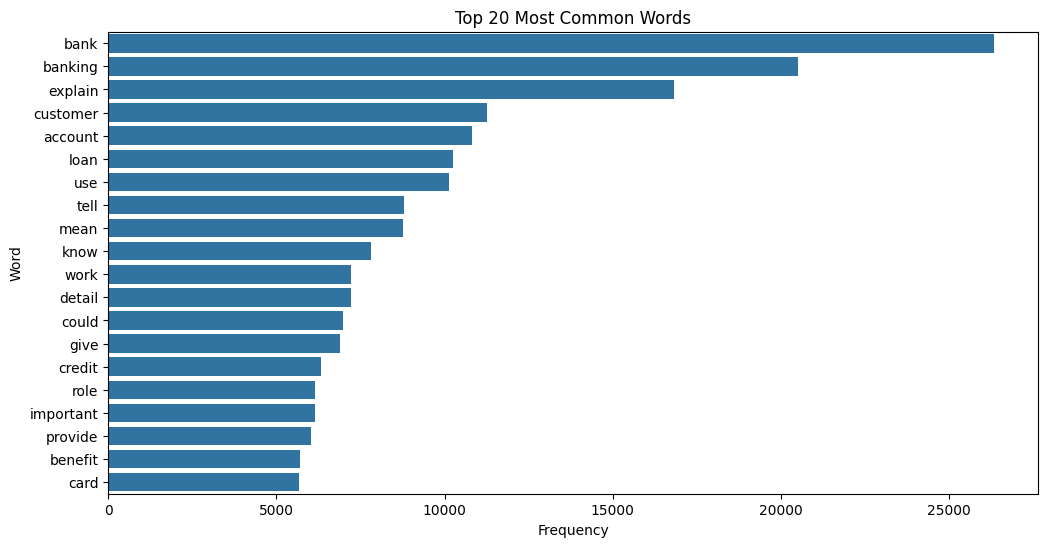

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Frequency',
    y='Word',
    data=common_words_df
)

plt.title("Top 20 Most Common Words")

plt.show()

### N-gram Analysis

#### Import N-grams

In [28]:
from nltk.util import ngrams

#### Generate Bigrams

In [29]:
bigrams = list(ngrams(all_words, 2))

#### Count Bigrams

In [30]:
bigram_freq = Counter(bigrams)

bigram_freq.most_common(10)

[(('play', 'banking'), 5148),
 (('could', 'describe'), 5082),
 (('use', 'banking'), 5053),
 (('provide', 'detail'), 5044),
 (('bank', 'manage'), 5011),
 (('customer', 'use'), 4996),
 (('give', 'overview'), 4985),
 (('customer', 'need'), 4973),
 (('explain', 'concept'), 4972),
 (('common', 'fact'), 4923)]

### Word Cloud

In [31]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(" ".join(all_words))

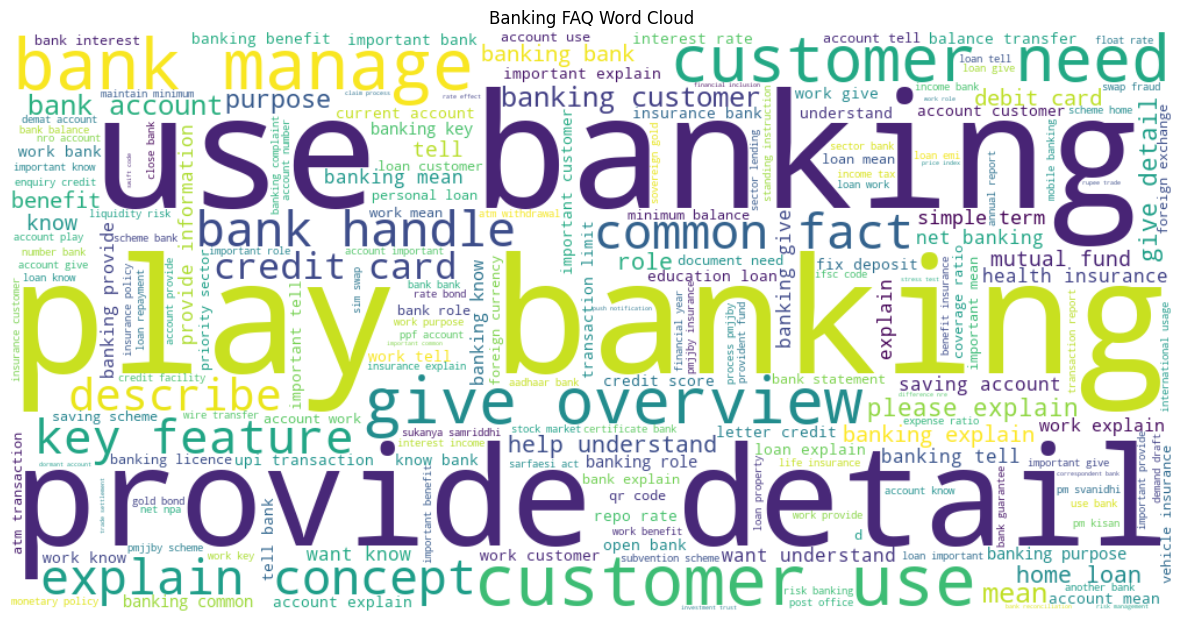

In [32]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Banking FAQ Word Cloud")

plt.show()

# Key Insights & Observations

## 1. Dataset Structure

- The dataset contains **127,930 banking FAQ records** with **3 text-based columns**:
  - `Section`
  - `Question`
  - `Answer`

- All columns are of `object` datatype because the dataset is completely text-oriented.

- The large dataset size provides strong support for:
  - NLP preprocessing
  - Text classification
  - Intent detection
  - Semantic search
  - RAG-based chatbot systems

---

## 2. Data Quality Analysis

### Missing Values
- No major missing values were detected in the dataset.
- The dataset is sufficiently clean for machine learning workflows.

### Duplicate Records
- Very few duplicate records were observed.
- Duplicate handling improves model generalization and reduces bias.

### Text Cleaning
- Text preprocessing included:
  - Lowercasing
  - Special character removal
  - Extra whitespace removal

- Cleaned text improves TF-IDF feature extraction quality.

---

## 3. Text Length Analysis

### Question Length Distribution
- Most questions contain approximately **20–40 words**.
- Peak question frequency occurs around **28–30 words**.
- The distribution is slightly right-skewed, indicating a few long queries.

### Answer Length Distribution
- Most answers contain approximately **130–170 words**.
- Peak answer frequency occurs around **145–155 words**.
- Answer lengths are relatively consistent across categories.

---

## 4. NLP Feature Engineering

### TF-IDF Vectorization
Two TF-IDF approaches were used:

#### Word-Level TF-IDF
- `ngram_range = (1,3)`
- Captures:
  - Unigrams
  - Bigrams
  - Trigrams

#### Character-Level TF-IDF
- `analyzer = 'char_wb'`
- `ngram_range = (3,5)`

- Character features improve robustness against:
  - Typographical errors
  - Partial words
  - Banking abbreviations

### Combined Features
- Word and character TF-IDF features were combined using sparse matrix stacking (`hstack`).
- Combined representations improved semantic understanding and classification performance.

---

## 5. Model Performance Analysis

Several machine learning models were evaluated:

| Model | Observation |
|---|---|
| Logistic Regression | Stable baseline performance |
| Naive Bayes | Fast but lower accuracy |
| Random Forest | Performed poorly on sparse TF-IDF vectors |
| LinearSVC | Best traditional ML performance |
| Ensemble Model | Improved overall robustness |

### Best Performing Model
- Tuned `LinearSVC` achieved the strongest overall performance.
- SVM handled high-dimensional sparse text data efficiently.

### Hyperparameter Tuning
GridSearchCV was applied for:
- Logistic Regression
- LinearSVC

This improved:
- Generalization
- Cross-validation accuracy
- Model stability

---

## 6. Overfitting Analysis

- Training and testing accuracies were compared for all models.
- Cross-validation scores remained relatively close to test accuracy.
- The models showed controlled overfitting behavior.

---

## 7. Semantic Understanding

The dataset contains rich banking terminology such as:
- UPI
- EMI
- SWIFT
- Debit card
- Loan processing
- Mutual funds

This makes the dataset suitable for:
- Banking intent classification
- FAQ automation
- Conversational AI systems
- Financial assistant chatbots

---

## 8. Overall Conclusion

- The dataset is clean, structured, and NLP-ready.
- Combined TF-IDF feature engineering significantly improved text representation quality.
- `LinearSVC` proved to be the most effective classical ML model for intent classification.
- The complete pipeline is suitable for:
  - Banking FAQ systems
  - Intent prediction APIs
  - Retrieval-Augmented Generation (RAG)
  - AI-powered customer support systems

### Save Clean Dataset

In [33]:
df.to_csv(
    "../data/banking_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
